In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

In [3]:
prelim_dir = os.path.expanduser("~/hpc-share/uvms/preliminary")
alpha_dir = prelim_dir+"/alpha"
beta_dir = prelim_dir+"/beta"

In [4]:
def sort_trials(trials):
    key_function = lambda s: int(s.split('_')[-1])
    sorted_trials = sorted(trials, key=key_function)
    return sorted_trials

def sort_csvs(csvs):
    key_function = lambda s: int(s.split('_')[-1].split('.')[0])
    sorted_csvs = sorted(csvs, key=key_function)
    return sorted_csvs

def filter_csvs(dirs):
    return [dir for dir in dirs if dir[-4:]=='.csv']

def get_fitnesses(experiment_dir):
    trials = sort_trials(os.listdir(experiment_dir))
    all_trial_fit = []
    for trial in trials:
        # We are looking at the csvs of one trial
        csvs = sort_csvs(filter_csvs(os.listdir(experiment_dir+'/'+trial)))
        # Right now I just want the best fitness at each generation
        trial_fit = []
        for csv in csvs:
            # A csv file is for a particular generation for a specific trial
            csv_dir = experiment_dir+'/'+trial+'/'+csv
            df = pd.read_csv(csv_dir)
            best_fit = min(df["fitness"])
            trial_fit.append(best_fit)

        # List of lists.
        # Main list : Each element is a trial
        # Each trial is a list of the best fitness at each generation for that trial
        all_trial_fit.append(trial_fit)
    return all_trial_fit

def plot_stats(all_trial_fit):
    # We may not have data for every gen of every trial
    # so let's cut down data to make sure we are only working with what we have
    all_trial_fit_pruned = []
    min_length = min([len(trial) for trial in all_trial_fit])
    for trial in all_trial_fit:
        all_trial_fit_pruned.append(trial[0:min_length])
    avg = np.average(all_trial_fit_pruned, axis=0)
    h_avg, = plt.plot(avg)
    std_dev = np.std(all_trial_fit_pruned, axis=0)
    std_err = std_dev/len(all_trial_fit_pruned)
    h_err = plt.fill_between(list(range(len(std_err))), avg+std_err, avg-std_err, alpha=0.1)
    return h_avg, h_err

def plot_all(all_trial_fit):
    hs = []
    for trial in all_trial_fit:
        hs.append(plt.plot(trial))
    return hs


In [5]:
alpha_fit = get_fitnesses(alpha_dir)
beta_fit = get_fitnesses(beta_dir)

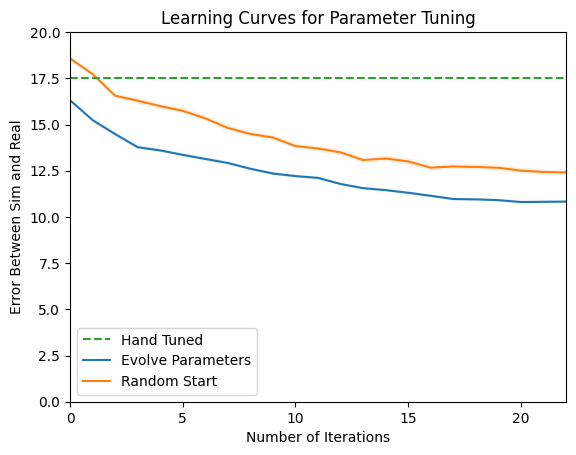

In [9]:
# Plot all of the best fitnesses
plt.rcParams['text.usetex'] = False

a_avg, a_err = plot_stats(alpha_fit)
b_avg, b_err = plot_stats(beta_fit)
h, = plt.plot([17.5137907382116 for _ in range(len(alpha_fit[0]))],'--')
plt.ylabel("Error Between Sim and Real")
plt.xlabel("Number of Iterations")
plt.title("Learning Curves for Parameter Tuning")
plt.xlim(0, 22)
plt.ylim(0,20)
plt.xticks([0,5,10,15,20])
plt.legend([h, a_avg, b_avg],["Hand Tuned", "Evolve Parameters", "Random Start"])
plt.savefig('prelim.svg')

Text(0.5, 1.0, 'Learning Curves for Parameter Tuning')

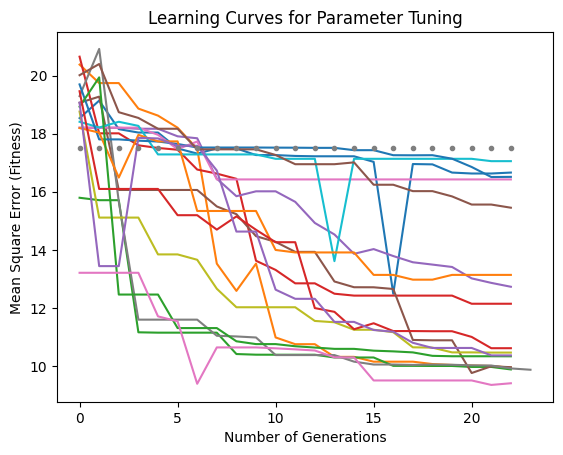

In [34]:
# Plot all of the best fitnesses
alpha_fit = get_fitnesses(alpha_dir)
beta_fit = get_fitnesses(beta_dir)
# for trial in alpha_fit:
#     plt.plot(trial)
for trial in beta_fit:
    plt.plot(trial)
plt.plot([17.5137907382116 for _ in range(len(trial))],'.')
plt.ylabel("Mean Square Error (Fitness)")
plt.xlabel("Number of Generations")
plt.title("Learning Curves for Parameter Tuning")